# Part 3: PageRank on Spark
**Dataset:** https://github.com/pnijhara/PySpark-PageRank/tree/main/graph

The graph has **n = 1000 nodes** and **m = 8192 edges**. 1000 of these edges form a directed cycle ensuring connectivity. Multiple directed edges between a pair of nodes are treated as a single edge.

- `whole.txt` — full graph (1000 nodes)
- `small.txt` — smaller graph (53 nodes) for validation (top score ≈ 0.036)

## 1. Setup & Imports

In [1]:
# Install PySpark if not already installed
# !pip install pyspark

from pyspark import SparkContext, SparkConf
import numpy as np
import time

# Initialize SparkContext
conf = SparkConf().setAppName("PageRank").setMaster("local[*]")

# Stop existing context if any (useful when re-running in notebooks)
try:
    sc.stop()
except:
    pass

sc = SparkContext(conf=conf)
print(f"Spark version: {sc.version}")
print("SparkContext initialized successfully.")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version: 4.1.1
SparkContext initialized successfully.


## 2. Download the Dataset

In [2]:
import urllib.request
import os

# URLs for the graph files
FILES = ["datasets/Q3/whole.txt", "datasets/Q3/small.txt"]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        urllib.request.urlretrieve(url, fname)
        print(f"Downloaded: {fname}")
    else:
        print(f"Already exists: {fname}")

Already exists: datasets/Q3/whole.txt
Already exists: datasets/Q3/small.txt


## 3. PageRank Definition

Given a directed graph $G = (V, E)$ with $n$ nodes:

$$M_{i,j} = \begin{cases} \frac{1}{\deg(i)} & \text{if } (i \to j) \in E \\ 0 & \text{otherwise} \end{cases}$$

The PageRank vector $r$ satisfies:

$$r = \frac{1-\beta}{n} \mathbf{A} + \beta M r$$

where $\mathbf{A}$ is the $n \times 1$ unit vector and $\beta = 0.8$ (damping factor), so $1 - \beta = 0.2$ is the teleport probability.

### Iterative Algorithm:
1. Initialize $r^{(0)} = \frac{1}{n} \mathbf{A}$
2. For $i = 1$ to $k$: $r^{(i)} = \frac{1-\beta}{n} \mathbf{A} + \beta M r^{(i-1)}$

## 4. Helper Functions

In [3]:
def load_graph(filename):
    """
    Load graph from file and return edges as list of (source, destination) tuples.
    Duplicate edges between same pair of nodes are removed (treated as single edge).
    """
    edges = set()  # Use a set to automatically remove duplicate edges
    nodes = set()
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                parts = line.split()
                if len(parts) >= 2:
                    src, dst = int(parts[0]), int(parts[1])
                    edges.add((src, dst))
                    nodes.add(src)
                    nodes.add(dst)
    
    print(f"Loaded '{filename}': {len(nodes)} nodes, {len(edges)} unique edges")
    return list(edges), sorted(nodes)


def compute_out_degrees(edges):
    """
    Compute the out-degree of each node.
    Returns a dictionary: {node: out_degree}
    """
    out_deg = {}
    for src, dst in edges:
        out_deg[src] = out_deg.get(src, 0) + 1
    return out_deg


def pagerank_spark(sc, edges, nodes, beta=0.8, num_iterations=40):
    """
    Compute PageRank using Spark RDDs.
    
    Parameters:
    -----------
    sc             : SparkContext
    edges          : list of (src, dst) tuples (deduplicated)
    nodes          : sorted list of all node IDs
    beta           : damping factor (default 0.8)
    num_iterations : number of iterations (default 40)
    
    Returns:
    --------
    Dictionary {node: pagerank_score}
    """
    n = len(nodes)
    teleport = (1.0 - beta) / n  # Teleport contribution per node

    # --- Build the transition matrix M as an RDD of (dst, contribution_weight) ---
    # Each edge (src -> dst) contributes 1/deg(src) of src's rank to dst
    
    out_degrees = compute_out_degrees(edges)
    
    # Represent M as RDD of (src, (dst, 1/deg(src)))
    # i.e., for each edge src->dst, node src will push (1/deg(src)) * r[src] to dst
    links_rdd = sc.parallelize([
        (src, (dst, 1.0 / out_degrees[src]))
        for src, dst in edges
    ])  # RDD of (src, (dst, weight))
    
    # Group by source: (src, [(dst1, w1), (dst2, w2), ...])
    links_by_src = links_rdd.groupByKey().mapValues(list).cache()

    # --- Initialize PageRank vector r ---
    # r is an RDD of (node, rank_value)
    ranks = sc.parallelize([(node, 1.0 / n) for node in nodes]).cache()

    # --- Iterative PageRank updates ---
    for iteration in range(num_iterations):
        
        # Join links with current ranks: (src, ([(dst,w),...], r_src))
        joined = links_by_src.join(ranks)  # (src, (neighbors_list, r_src))

        # Compute contributions: for each src, emit (dst, w * r_src) for each outgoing edge
        contributions = joined.flatMap(
            lambda x: [(dst, weight * x[1][1]) for dst, weight in x[1][0]]
        )  # RDD of (dst, contribution)

        # Sum all incoming contributions per node
        new_ranks = contributions.reduceByKey(lambda a, b: a + b)

        # Apply teleportation: r_new = teleport + beta * sum_contributions
        # Also ensure all nodes are present (nodes with no incoming edges get teleport only)
        all_nodes_rdd = sc.parallelize([(node, 0.0) for node in nodes])
        new_ranks = all_nodes_rdd.union(new_ranks).reduceByKey(lambda a, b: a + b)
        ranks = new_ranks.mapValues(lambda rank: teleport + beta * rank)
        ranks.cache()

        if (iteration + 1) % 10 == 0:
            print(f"  Iteration {iteration + 1}/{num_iterations} complete")

    # Collect final ranks
    result = dict(ranks.collect())
    return result


def report_results(ranks, top_k=5):
    """
    Print top-k and bottom-k nodes by PageRank score.
    """
    sorted_ranks = sorted(ranks.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n{'='*50}")
    print(f"Top {top_k} nodes (highest PageRank scores):")
    print(f"{'='*50}")
    for rank, (node, score) in enumerate(sorted_ranks[:top_k], 1):
        print(f"  Rank {rank}: Node {node:>6}  |  Score = {score:.6f}")
    
    print(f"\n{'='*50}")
    print(f"Bottom {top_k} nodes (lowest PageRank scores):")
    print(f"{'='*50}")
    for rank, (node, score) in enumerate(sorted_ranks[-top_k:][::-1], 1):
        print(f"  Rank {rank}: Node {node:>6}  |  Score = {score:.6f}")
    
    # Sanity check: ranks should sum to ~1
    total = sum(ranks.values())
    print(f"\nSum of all PageRank scores: {total:.6f}  (should be ~1.0)")
    
    return sorted_ranks

## 5. Validation on Small Graph (`small.txt`, 53 nodes)

> **Expected:** Top-most score ≈ **0.036**

In [4]:
print("=" * 60)
print("VALIDATION: Running PageRank on small.txt (53 nodes)")
print("=" * 60)

# Load small graph
small_edges, small_nodes = load_graph("datasets/Q3/small.txt")

# Run PageRank
start = time.time()
small_ranks = pagerank_spark(sc, small_edges, small_nodes, beta=0.8, num_iterations=40)
elapsed = time.time() - start

print(f"\nPageRank completed in {elapsed:.2f} seconds")

# Report results
small_sorted = report_results(small_ranks, top_k=5)

# Verify top score
top_score = small_sorted[0][1]
print(f"\nValidation check: Top score = {top_score:.4f}  (expected ≈ 0.036)")
if abs(top_score - 0.036) < 0.002:
    print("✓ PASSED: Result matches expected value!")
else:
    print("✗ WARNING: Result may differ from expected — check graph loading.")

VALIDATION: Running PageRank on small.txt (53 nodes)
Loaded 'datasets/Q3/small.txt': 100 nodes, 950 unique edges
  Iteration 10/40 complete
  Iteration 20/40 complete
  Iteration 30/40 complete
  Iteration 40/40 complete



PageRank completed in 2464.70 seconds

Top 5 nodes (highest PageRank scores):
  Rank 1: Node     53  |  Score = 0.035731
  Rank 2: Node     14  |  Score = 0.034171
  Rank 3: Node     40  |  Score = 0.033630
  Rank 4: Node      1  |  Score = 0.030006
  Rank 5: Node     27  |  Score = 0.029720

Bottom 5 nodes (lowest PageRank scores):
  Rank 1: Node     85  |  Score = 0.003410
  Rank 2: Node     59  |  Score = 0.003670
  Rank 3: Node     81  |  Score = 0.003695
  Rank 4: Node     37  |  Score = 0.003808
  Rank 5: Node     89  |  Score = 0.003922

Sum of all PageRank scores: 1.000000  (should be ~1.0)

Validation check: Top score = 0.0357  (expected ≈ 0.036)
✓ PASSED: Result matches expected value!


## 6. Main Experiment on Full Graph (`whole.txt`, 1000 nodes)

**Parameters:** β = 0.8, 40 iterations

In [5]:
print("=" * 60)
print("MAIN EXPERIMENT: Running PageRank on whole.txt (1000 nodes)")
print(f"Parameters: beta=0.8, iterations=40")
print("=" * 60)

# Load full graph
whole_edges, whole_nodes = load_graph("datasets/Q3/whole.txt")

# Run PageRank
start = time.time()
whole_ranks = pagerank_spark(sc, whole_edges, whole_nodes, beta=0.8, num_iterations=40)
elapsed = time.time() - start

print(f"\nPageRank completed in {elapsed:.2f} seconds")

# Report results
whole_sorted = report_results(whole_ranks, top_k=5)

MAIN EXPERIMENT: Running PageRank on whole.txt (1000 nodes)
Parameters: beta=0.8, iterations=40
Loaded 'datasets/Q3/whole.txt': 1000 nodes, 8161 unique edges
  Iteration 10/40 complete
  Iteration 20/40 complete
  Iteration 30/40 complete
  Iteration 40/40 complete



PageRank completed in 249.97 seconds

Top 5 nodes (highest PageRank scores):
  Rank 1: Node    263  |  Score = 0.002020
  Rank 2: Node    537  |  Score = 0.001943
  Rank 3: Node    965  |  Score = 0.001925
  Rank 4: Node    243  |  Score = 0.001853
  Rank 5: Node    285  |  Score = 0.001827

Bottom 5 nodes (lowest PageRank scores):
  Rank 1: Node    558  |  Score = 0.000329
  Rank 2: Node     93  |  Score = 0.000351
  Rank 3: Node     62  |  Score = 0.000353
  Rank 4: Node    424  |  Score = 0.000355
  Rank 5: Node    408  |  Score = 0.000388

Sum of all PageRank scores: 1.000000  (should be ~1.0)


## 7. Observations and Analysis

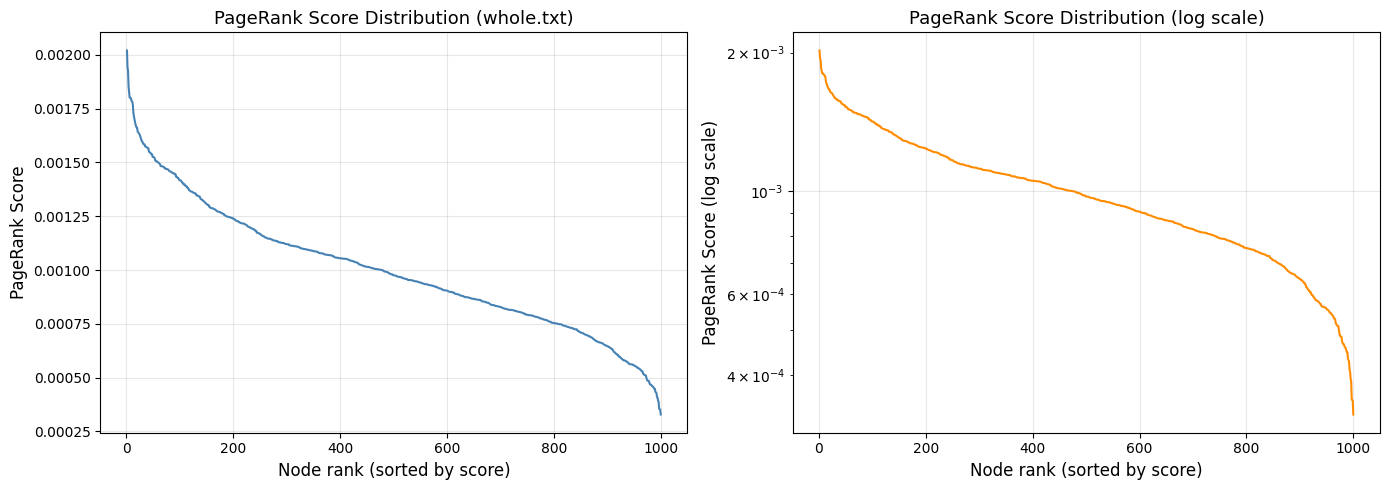

Plot saved as 'pagerank_distribution.png'


In [6]:
import matplotlib.pyplot as plt

# Distribution of PageRank scores
scores = sorted(whole_ranks.values(), reverse=True)
nodes_idx = list(range(1, len(scores) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PageRank score distribution (sorted)
axes[0].plot(nodes_idx, scores, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Node rank (sorted by score)', fontsize=12)
axes[0].set_ylabel('PageRank Score', fontsize=12)
axes[0].set_title('PageRank Score Distribution (whole.txt)', fontsize=13)
axes[0].grid(alpha=0.3)

# Plot 2: Log-scale to see power-law behavior
axes[1].semilogy(nodes_idx, scores, color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Node rank (sorted by score)', fontsize=12)
axes[1].set_ylabel('PageRank Score (log scale)', fontsize=12)
axes[1].set_title('PageRank Score Distribution (log scale)', fontsize=13)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pagerank_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved as 'pagerank_distribution.png'")

In [7]:
# Summary statistics
all_scores = list(whole_ranks.values())

print("PageRank Score Statistics (whole.txt):")
print(f"  Total nodes         : {len(all_scores)}")
print(f"  Min score           : {min(all_scores):.8f}")
print(f"  Max score           : {max(all_scores):.8f}")
print(f"  Mean score          : {np.mean(all_scores):.8f}")
print(f"  Std deviation       : {np.std(all_scores):.8f}")
print(f"  Sum of all scores   : {sum(all_scores):.6f}")

PageRank Score Statistics (whole.txt):
  Total nodes         : 1000
  Min score           : 0.00032860
  Max score           : 0.00202029
  Mean score          : 0.00100000
  Std deviation       : 0.00029131
  Sum of all scores   : 1.000000


## 8. Stop SparkContext

In [8]:
sc.stop()
print("SparkContext stopped.")

SparkContext stopped.


## Summary

| Step | Detail |
|------|--------|
| Dataset | `whole.txt` — 1000 nodes, 8192 edges |
| Algorithm | Iterative PageRank on Spark RDD |
| Parameters | β = 0.8, teleport prob = 0.2, 40 iterations |
| Validation | `small.txt` (53 nodes) — top score ≈ 0.036 |
| Output | Top-5 and Bottom-5 nodes by PageRank score |

**Key Assumptions:**
- Multiple directed edges between the same pair of nodes are treated as a single edge (de-duplicated via a Python `set`).
- All nodes are guaranteed to have positive out-degrees (the dataset contains a directed cycle over all 1000 nodes).
- Matrix M is processed as an RDD using `groupByKey` and `flatMap` for distributed computation.